In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input


from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Dense, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras import regularizers, layers
from tensorflow.keras.metrics import Precision, Recall
from tensorflow import keras

from sklearn.metrics import confusion_matrix, precision_recall_curve, precision_score, recall_score, f1_score, accuracy_score, average_precision_score, classification_report
from sklearn.preprocessing import label_binarize

In [21]:
(train_cat_dog, test_cat_dog) = tfds.load('cats_vs_dogs',
                                split=['train[:70%]', 'train[70%:]'],
                                shuffle_files=True,
                                as_supervised=True)

In [22]:
(train_horse_human, test_horse_human) = tfds.load('horses_or_humans',
                                split=['train', 'test'],
                                shuffle_files=True,
                                as_supervised=True)

In [24]:
def preprocess_for_inc(image, label):
    image = tf.image.resize(image, (150, 150))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [25]:
train_horse_human = train_horse_human.map(
        lambda x, y: preprocess_for_inc(x, y)
    )
test_horse_human = test_horse_human.map(
        lambda x, y: preprocess_for_inc(x, y)
    )

train_cat_dog = train_cat_dog.map(
        lambda x, y: preprocess_for_inc(x, y)
    )
test_cat_dog = test_cat_dog.map(
        lambda x, y: preprocess_for_inc(x, y)
    )

In [26]:
train_horse_human = train_horse_human.batch(32).prefetch(tf.data.AUTOTUNE)
test_horse_human = test_horse_human.batch(32).prefetch(tf.data.AUTOTUNE)

train_cat_dog = train_cat_dog.batch(32).prefetch(tf.data.AUTOTUNE)
test_cat_dog = test_cat_dog.batch(32).prefetch(tf.data.AUTOTUNE)

In [27]:
model_inc = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3))
model_inc.trainable = False

model = Sequential([
        model_inc,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='sigmoid')
    ])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )


In [28]:
history = model.fit(
    train_horse_human,
    epochs=10,
    validation_data=test_horse_human
)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 29s 621ms/step - accuracy: 0.8044 - loss: 1.8120 - val_accuracy: 1.0000 - val_loss: 3.4739e-04
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 24s 154ms/step - accuracy: 0.9973 - loss: 0.0227 - val_accuracy: 1.0000 - val_loss: 1.6041e-05
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.9987 - loss: 0.0077 - val_accuracy: 1.0000 - val_loss: 1.7374e-05
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.9992 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 8.4844e-05
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 202ms/step - accuracy: 0.9967 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 6.0774e-05
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 1.0000 - loss: 4.8267e-04 - val_accuracy: 1.0000 - val_loss: 8.1464e-05
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 1.0000 - loss: 1.5611e-04 - val_accuracy: 1.0000 - val_loss: 1.4527e-04
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - accuracy: 1.

In [29]:
model_inc1 = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3))
model_inc1.trainable = False

model1 = Sequential([
        model_inc1,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='sigmoid')
    ])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

In [30]:
history1 = model1.fit(
    train_cat_dog,
    epochs=10,
    validation_data=test_cat_dog
)

Epoch 1/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 62s 98ms/step - accuracy: 0.9289 - loss: 0.3326 - val_accuracy: 0.9633 - val_loss: 0.0925
Epoch 2/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.9615 - loss: 0.0971 - val_accuracy: 0.9663 - val_loss: 0.0854
Epoch 3/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.9672 - loss: 0.0846 - val_accuracy: 0.9673 - val_loss: 0.0925
Epoch 4/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.9682 - loss: 0.0851 - val_accuracy: 0.9666 - val_loss: 0.0862
Epoch 5/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.9721 - loss: 0.0670 - val_accuracy: 0.9659 - val_loss: 0.0972
Epoch 6/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.9737 - loss: 0.0690 - val_accuracy: 0.9685 - val_loss: 0.0914
Epoch 7/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.9751 - loss: 0.0619 - val_accuracy: 0.9656 - val_loss: 0.1014
Epoch 8/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.9773 - loss: 0.0553 - 

In [44]:
def ev_model(model, test_data):
    y_true = []
    y_pred_proba = []

    for images, labels in test_data:
        y_true.extend(labels.numpy())
        pred = model.predict(images, verbose=0)
        y_pred_proba.extend(pred)

    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)

    y_pred = np.argmax(y_pred_proba, axis=1)
    y_score = y_pred_proba[:, 1]


    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')


    plt.subplot(1, 3, 2)
    report = classification_report(y_true, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='Blues')
    plt.title('Classification Report')


    plt.subplot(1, 3, 3)
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    average_precision = average_precision_score(y_true, y_score)

    plt.plot(recall, precision, color='darkorange', lw=2,
             label=f'PR-кривая (AP = {average_precision:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall кривая')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [40]:
def plot_training_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

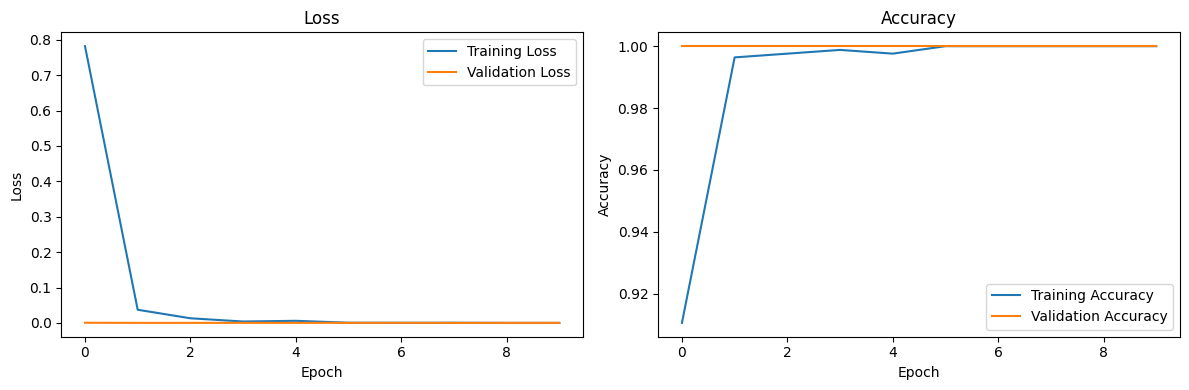

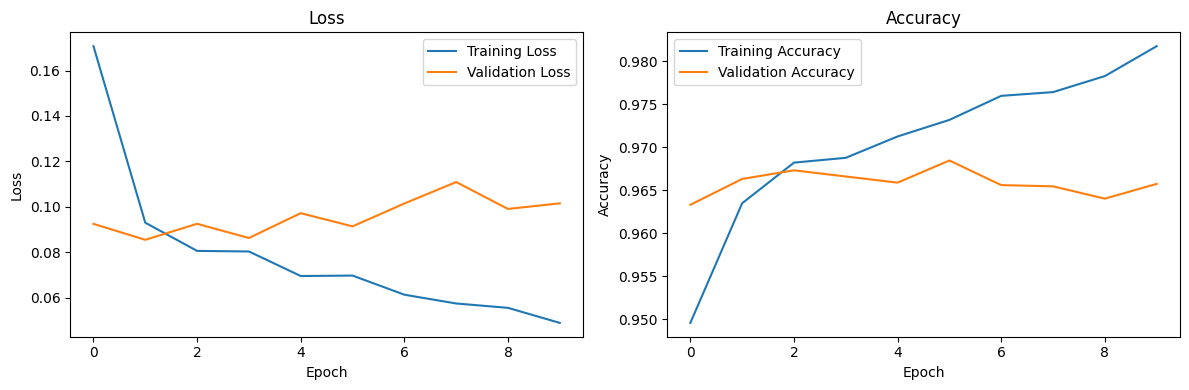

In [41]:
plot_training_history(history)
plot_training_history(history1)

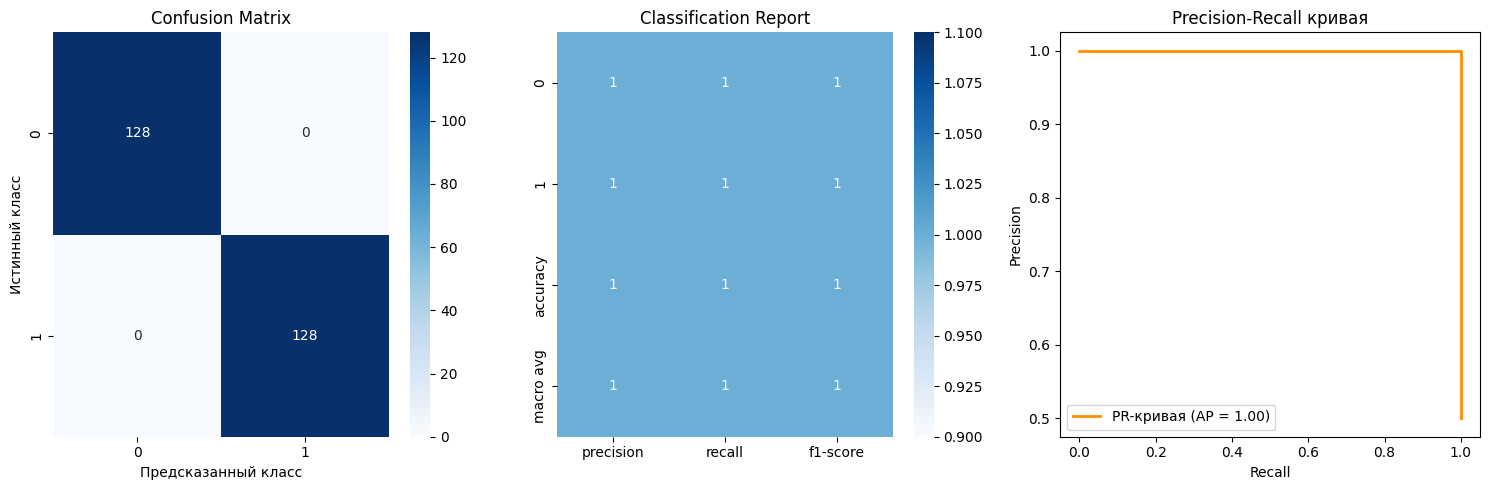

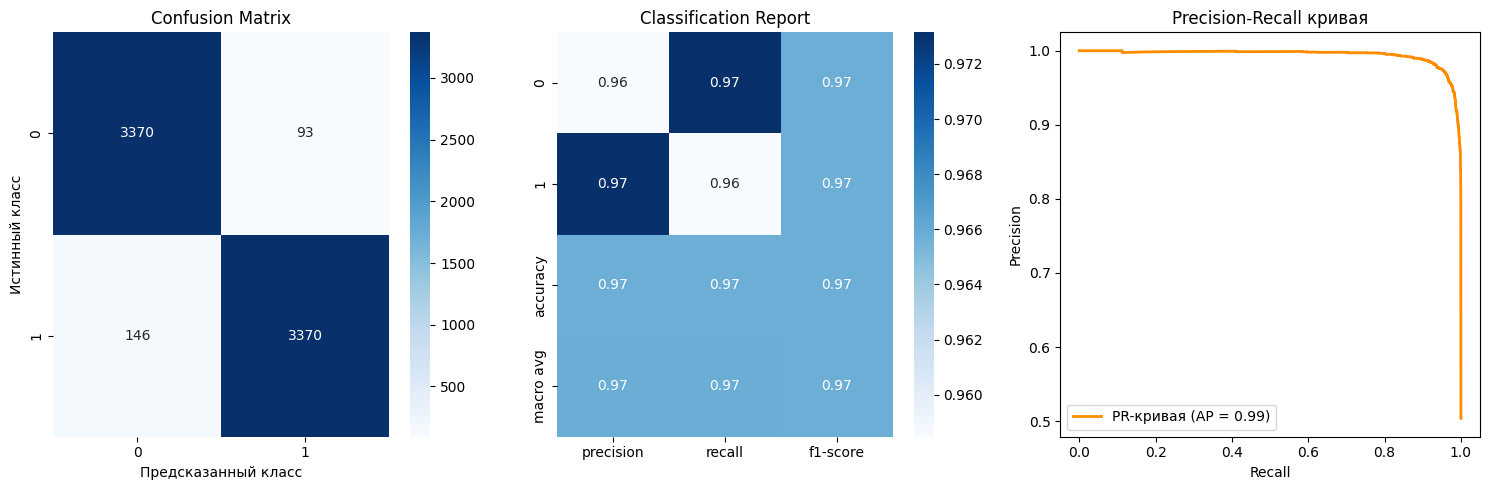

In [45]:
ev_model(model, test_horse_human)
ev_model(model1, test_cat_dog)

Обе модели показывают хороший результат за исключением Horses vs Humans, тут имеется явное переобучение, как у Cats vs Dogs показывает хороший результат. Для улучшения можно упросить модель для HvH. На обоих графиках показывается хороший результат PR кривой.